In [7]:
import seaborn
import matplotlib.pyplot as plt
from libpysal.weights import lag_spatial
import geopandas as gpd
from libpysal.weights import KNN

In [2]:
# setting wd 
import os
os.chdir('/users/ctlin/fooddesertproject')

In [3]:
county = "harris"

In [4]:
gdf = gpd.read_file(f"modeling_data/{county}_modeling_final.gpkg")
print(gdf.shape)  

(1289, 24)


In [5]:
# only use when calculating k, otherwise comment out 
n = len(gdf)
k = round(n ** (1/3))
print(f"Number of census tracts: {n}")
print(f"Cube root of n: {n**(1/3):.2f}")
print(f"Selected k: {k}")

Number of census tracts: 1289
Cube root of n: 10.88
Selected k: 11


In [8]:
gdf = gpd.read_file(f"modeling_data/{county}_modeling_final.gpkg")
w1 = KNN.from_dataframe(gdf, k=k, use_index=True)

In [9]:
# standardize your variable (subtract the mean) — makes the plot easier to read
gdf["var_std"] = gdf["E_DIABETES"] - gdf["E_DIABETES"].mean()

In [10]:
# compute the spatial lag — average of each tract's neighbors
w1.transform = "R"  # row-standardize for the plot (safe here since you're not calling higher_order after this)
gdf["var_lag_std"] = lag_spatial(w1, gdf["var_std"])

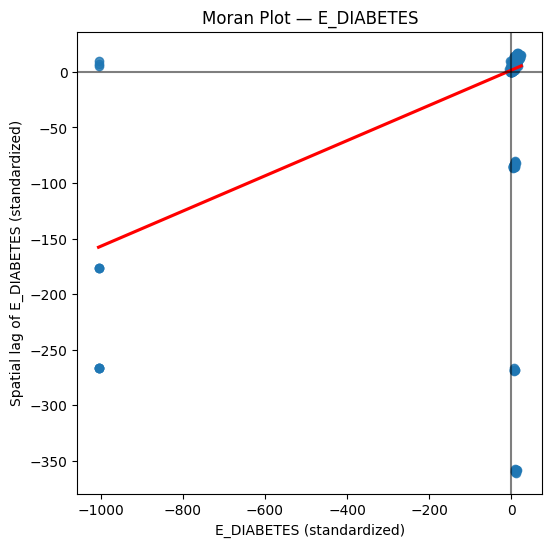

In [11]:
# plot
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="var_std", y="var_lag_std", data=gdf,
    ci=None, line_kws={"color": "r"}
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_xlabel("E_DIABETES (standardized)")
ax.set_ylabel("Spatial lag of E_DIABETES (standardized)")
ax.set_title("Moran Plot — E_DIABETES")
plt.savefig(f"{county}_moran_plot_diabetes.png", dpi=200, bbox_inches="tight")
plt.show()